# 03 Player Profile Features

Sprint 3 — left-join `valuation_targets` with `players.csv` to attach player profile features (age, position, foot, country, contract status). No performance features yet.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.config import INTERIM_DATA_DIR, METRICS_DIR, RAW_DATA_DIR
from src.load_data import _resolve_raw_path, load_csv_file
from src.features import (
    add_player_profile_features,
    build_player_profile_summary,
    prepare_players,
    save_player_profile_dataset,
    save_player_profile_summary,
    validate_player_profile_dataset,
)

In [2]:
targets = pd.read_parquet(INTERIM_DATA_DIR / 'valuation_targets.parquet')
players_raw = load_csv_file(_resolve_raw_path(RAW_DATA_DIR, 'players.csv'))
players = prepare_players(players_raw)
print('targets:', targets.shape, '| players:', players.shape)

  loaded players.csv.gz: shape=(47637, 26)
targets: (476307, 14) | players: (47637, 24)


## Join + feature derivation

In [3]:
enriched = add_player_profile_features(targets, players)
validate_player_profile_dataset(enriched, expected_rows=len(targets))
print('final:', enriched.shape)
enriched[['player_id','player_name','valuation_date','age_at_valuation','age_bucket','position','foot']].head(10)

final: (476307, 40)


,player_id,player_name,valuation_date,age_at_valuation,age_bucket,position,foot
0,10,Miroslav Klose,2004-10-04,26.321697,26-29,Attack,right
1,10,Miroslav Klose,2005-01-07,26.581793,26-29,Attack,right
2,10,Miroslav Klose,2005-05-05,26.904860,26-29,Attack,right
3,10,Miroslav Klose,2005-09-30,27.310062,26-29,Attack,right
4,10,Miroslav Klose,2006-01-09,27.586585,26-29,Attack,right
5,10,Miroslav Klose,2006-07-15,28.098563,26-29,Attack,right
6,10,Miroslav Klose,2007-06-21,29.032170,26-29,Attack,right
7,10,Miroslav Klose,2008-06-04,29.987680,26-29,Attack,right
8,10,Miroslav Klose,2009-06-10,31.003422,30-33,Attack,right
9,10,Miroslav Klose,2009-08-30,31.225188,30-33,Attack,right


## Distributions

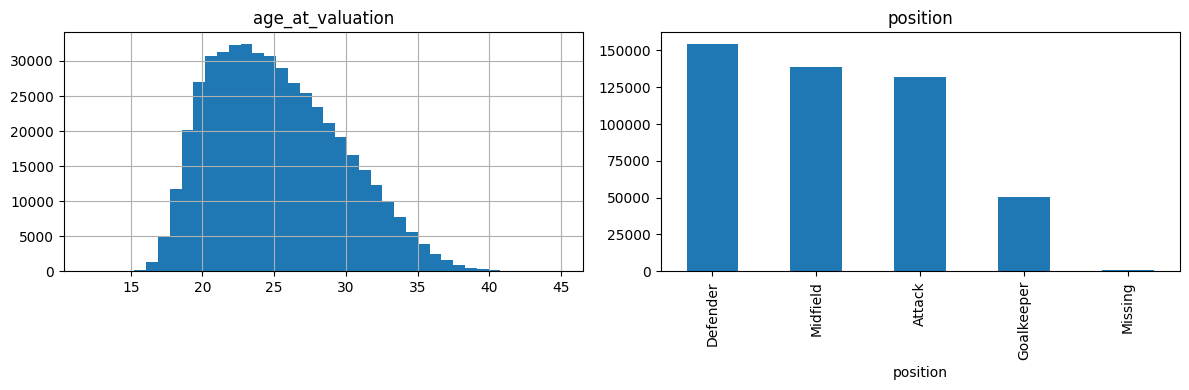

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
enriched['age_at_valuation'].dropna().hist(bins=40, ax=axes[0])
axes[0].set_title('age_at_valuation')
enriched['position'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('position')
plt.tight_layout()
plt.show()

## Persist artefacts

In [5]:
save_player_profile_dataset(enriched, INTERIM_DATA_DIR / 'player_profile_features.parquet')
summary = build_player_profile_summary(enriched)
save_player_profile_summary(summary, METRICS_DIR / 'player_profile_summary.json')
summary

Player profile dataset written to C:\football_market_value-dl\data\interim\player_profile_features.parquet
Player profile summary written to C:\football_market_value-dl\reports\metrics\player_profile_summary.json


{'rows': 476307,
 'unique_players': 30637,
 'min_valuation_date': '2000-01-20',
 'max_valuation_date': '2025-12-19',
 'missing_player_name_pct': 0.0,
 'missing_age_at_valuation_pct': 0.12,
 'min_age_at_valuation': 11.96,
 'median_age_at_valuation': 24.7,
 'max_age_at_valuation': 44.9,
 'age_bucket_counts': {'22-25': 150394,
  '18-21': 124477,
  '26-29': 112806,
  '30-33': 61210,
  '34+': 17176,
  'U18': 9674},
 'position_counts': {'Defender': 154550,
  'Midfield': 138495,
  'Attack': 131989,
  'Goalkeeper': 50568,
  'Missing': 705},
 'sub_position_top_20': {'Centre-Back': 87063,
  'Centre-Forward': 70095,
  'Central Midfield': 53865,
  'Goalkeeper': 50568,
  'Defensive Midfield': 42393,
  'Right-Back': 34615,
  'Attacking Midfield': 33130,
  'Left-Back': 32872,
  'Left Winger': 29224,
  'Right Winger': 28614,
  'Left Midfield': 4797,
  'Right Midfield': 4310,
  'Second Striker': 4056},
 'foot_counts': {'right': 328141, 'left': 113959, 'both': 22046},
 'country_top_20': {'Spain': 34171,